<a href="https://colab.research.google.com/github/c-marq/CAP3321C-Data-Wrangling/blob/main/[PATH]/case-study-laptops-starter.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Laptops Case Study: Section 1

**CAP3321C Data Wrangling** | Group lab | Miami Dade College

**Scenario.** You are an analyst employed by a computer hardware company that will be entering the laptop market soon. Your boss has asked you to produce a report that answers five questions about laptops to help the company understand the market.

**How this notebook works.** The setup cell loads the data. After that, every question has three cells: a heading, a code cell for your analysis, and a markdown cell where you write what the table or plot tells you. Your boss reads the markdown, not the code. Keep this notebook clean; you will extend it for your final (section 2 of this case study).

**Notebook requirements**
- A markdown heading for every question
- A table or plot that answers it
- A short written summary under each answer
- Comments or markdown explaining any cleaning decision and any code that is not obvious

**Group Members:**
- Name 1: Alex Rivera
- Name 2:
- Name 3:
- Name 4:

**Roles:** Lead Coder / Data Interpreter / Presenter / QA Reviewer

## Setup

In [ ]:
# Run this cell. Do not modify.
import pandas as pd
import matplotlib.pyplot as plt

url = "https://raw.githubusercontent.com/c-marq/CAP3321C-Data-Wrangling/main/data/laptops.csv"
laptops_df = pd.read_csv(url)

print(laptops_df.shape)
laptops_df.head()

(205, 9)


,brand,laptop_name,display_size,processor_type,graphics_card,disk_space,discount_price,old_price,ratings_5max
0,HP,Notebook 14-df0008nx,14.0,Intel Celeron N4000,Intel HD Graphics 600,64 GB (eMMC),1259.0,1259.0,0 / 5
1,Lenovo,IdeaPad 330S-14IKB,14.0,Intel Core i5-8250U,Intel UHD Graphics 620,1 TB HDD,1849.0,2099.0,3.3 / 5
2,Huawei,MateBook D Volta,14.0,Intel Core i5-8250U,NVIDIA GeForce MX150 (2 GB),256 GB SSD,2999.0,3799.0,0 / 5
3,Dell,Inspiron 15 3567,15.6,Intel Core i3-7020U,Intel HD Graphics 620,1 TB HDD,1849.0,1849.0,0 / 5
4,Asus,VivoBook 15 X510UR,15.6,Intel Core i7-8550U,NVIDIA GeForce 930MX (2 GB),1 TB HDD,2499.0,3149.0,0 / 5


**Checkpoint.** The shape should be `(205, 9)`. If it is not, re-run the setup cell.

## Explore and clean the data

Before answering anything, get to know the file. Use `info()`, `describe()`, `isna().sum()`, and `value_counts()` on the columns you plan to use. Then make your cleaning decisions and **explain them in the markdown cell below the code**.

In [ ]:
# basic information about the dataset
laptops_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 205 entries, 0 to 204
Data columns (total 9 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   brand           205 non-null    object 
 1   laptop_name     204 non-null    object 
 2   display_size    205 non-null    float64
 3   processor_type  205 non-null    object 
 4   graphics_card   205 non-null    object 
 5   disk_space      205 non-null    object 
 6   discount_price  205 non-null    float64
 7   old_price       205 non-null    float64
 8   ratings_5max    205 non-null    object 
dtypes: float64(3), object(6)
memory usage: 14.5+ KB


In [ ]:
# summary statistics
laptops_df.describe()

,display_size,discount_price,old_price
count,205.000000,205.000000,205.000000
mean,14.579805,3812.550976,4040.355854
std,1.109458,2308.702005,2327.147396
min,12.000000,899.000000,999.000000
25%,13.300000,2099.000000,2249.000000
50%,14.000000,3149.000000,3299.000000
75%,15.600000,4939.000000,5649.000000
max,18.400000,12499.000000,12499.000000


In [ ]:
# check for missing values
laptops_df.isna().sum()

,0
brand,0
laptop_name,1
display_size,0
processor_type,0
graphics_card,0
disk_space,0
discount_price,0
old_price,0
ratings_5max,0


In [ ]:
# check the brands
laptops_df['brand'].value_counts()

,count
brand,
HP,48
Apple,38
Dell,34
Acer,24
Lenovo,23
Asus,22
Huawei,12
Microsoft,3
MSI,1


In [ ]:
# check the display sizes
laptops_df['display_size'].value_counts()

,count
display_size,
15.60,84
14.00,49
13.30,48
15.40,9
13.00,3
17.30,3
13.50,3
12.00,2
13.88,2


In [ ]:
# Clean: apply any changes you decided on (drop rows, fix types, filter categories)
# No rows need to be dropped for Section 1.
# We will use discount_price as the laptop price.

**Things to look at in this dataset**
- Run `info()`. Two columns you would expect to be numbers are text: `ratings_5max` (values like `3.3 / 5`) and `disk_space` (values like ` 256 GB SSD`). Decide whether any section 1 question needs them as numbers.
- One row has a missing `laptop_name`. Decide whether to keep it.
- There are two price columns, `discount_price` and `old_price`. Decide which one means "price" for your report and use it consistently.

**Our cleaning decisions and why:**

I kept the row with the missing laptop name because the rest of the data is still useful. I did not change ratings_5max or disk_space because they are not needed for these questions. I used discount_price as the laptop price.

## Question 1: How many different laptop brands are there?

*Hint: One method call on one column. List the brands too, not just the count.*

In [ ]:
# Question 1
# number of brands
laptops_df['brand'].nunique()

9

In [ ]:
# list of brands
laptops_df['brand'].unique()

array(['HP', 'Lenovo', 'Huawei', 'Dell', 'Asus', 'Apple', 'Acer',
       'Microsoft', 'MSI'], dtype=object)

**Summary for Question 1:**

There are 9 different laptop brands in the dataset.

## Question 2: What are the names and prices of the most and least expensive laptops?

*Hint: Find the row with the highest price and the row with the lowest, then show the name and price from each. `idxmax()` and `idxmin()` are one route; sorting is another.*

In [ ]:
# Question 2
# most expensive laptop
laptops_df.loc[ laptops_df['discount_price'].idxmax(), ['laptop_name', 'discount_price'] ]


,132
laptop_name,MacBook Pro (Retina + Touch Bar)
discount_price,12499.0


In [ ]:
# least expensive laptop
laptops_df.loc[ laptops_df['discount_price'].idxmin(), ['laptop_name', 'discount_price'] ]

,74
laptop_name,IdeaPad S130-14IGM
discount_price,899.0


**Summary for Question 2:**

The most expensive laptop is the MacBook Pro (Retina + Touch Bar) at 12,499. The least expensive is the Lenovo IdeaPad S130-14IGM at 899.

## Question 3: How are laptop prices distributed?

*Hint: A histogram. Then describe the shape in words: where is the bulk, and are there outliers?*

Text(0.5, 0, 'Price')

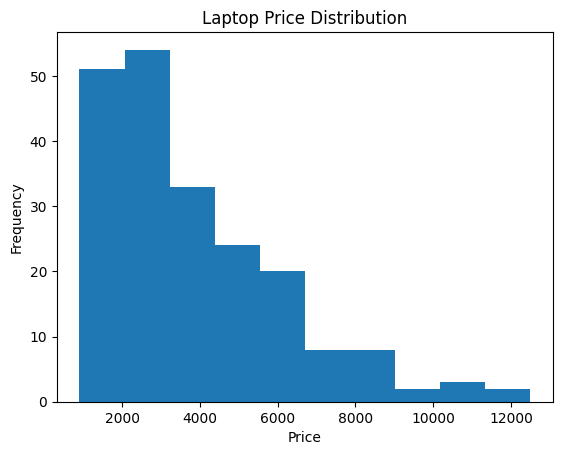

In [ ]:
# Question 3
# laptop price histogram
laptops_df['discount_price'].plot.hist( title='Laptop Price Distribution' )
plt.xlabel('Price')


**Summary for Question 3:**

Most laptops are in the lower price range, with a few laptops that are much more expensive.

## Question 4: What are the min, max, and mean display sizes?

*Hint: One line if you pick the right method.*

In [ ]:
# display size statistics
laptops_df['display_size'].agg(['min', 'max', 'mean'])


,display_size
min,12.000000
max,18.400000
mean,14.579805


**Summary for Question 4:**
The display sizes range from 12 inches to 18.4 inches

## Question 5: What is the average price for each brand?

*Hint: `groupby()` on brand, then a mean. Sort the result so the story is obvious.*

In [ ]:
# average price by brand
laptops_df.groupby('brand')['discount_price'].mean().sort_values(ascending=False)

,discount_price
brand,
MSI,9071.000000
Apple,6802.025000
Microsoft,5132.333333
Dell,3782.911765
Huawei,3615.666667
HP,3226.916667
Asus,2972.636364
Acer,2515.583333
Lenovo,1998.130435


**Summary for Question 5:**

MSI has the highest average laptop price at about 9,071, while Lenovo has the lowest at about 1,998. Apple has the second highest average price at about 6,802.


## Share-out

Pick the one question your group found most interesting or most surprising. The Presenter will show that table or plot and explain it in under three minutes.

**Question we are presenting:**

**Why:**

## Before you leave

1. Every question has a heading, an answer, and a written summary.
2. Every cleaning decision is explained.
3. Runtime menu, then *Restart and run all*. The whole notebook should run top to bottom without errors.
4. Every group member downloads a copy (File menu, then *Download .ipynb*). You will need this notebook for the final.